<a href="https://colab.research.google.com/github/Mat9408/Atividades_CursoAnalistaDeDados_EBAC/blob/main/M%C3%B3dulo_13_Tarefa_Finalizado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Data Wrangling

###Extração dos dados dos Estados

In [ ]:
''' Fazendo a leitura do arquivo estados-bruto.xml'''

from bs4 import BeautifulSoup
import pandas as pd

nome_arquivo_fonte = 'estados-bruto.xml'

fonte = BeautifulSoup(open('estados-bruto.xml', mode='r'),'lxml')

In [ ]:
'Visualização do arquivo'
fonte

<?xml version="1.0" encoding="utf-8" ?><html><body><estados>
<estado>
<id>1</id>
<nome>ACRE</nome>
<idcapital>16</idcapital>
<sigla>AC</sigla>
<regiao>NORTE</regiao>
</estado>
<estado>
<id>2</id>
<nome>ALAGOAS</nome>
<idcapital>68</idcapital>
<sigla>AL</sigla>
<regiao>NORDESTE</regiao>
</estado>
<estado>
<id>3</id>
<nome>AMAPA</nome>
<idcapital>131</idcapital>
<sigla>AP</sigla>
<regiao>NORTE</regiao>
</estado>
<estado>
<id>4</id>
<nome>AMAZONAS</nome>
<idcapital>178</idcapital>
<sigla>AM</sigla>
<regiao>NORTE</regiao>
</estado>
<estado>
<id>5</id>
<nome>BAHIA</nome>
<idcapital>536</idcapital>
<sigla>BA</sigla>
<regiao>NORDESTE</regiao>
</estado>
<estado>
<id>6</id>
<nome>CEARA</nome>
<idcapital>676</idcapital>
<sigla>CE</sigla>
<regiao>NORDESTE</regiao>
</estado>
<estado>
<id>7</id>
<nome>DISTRITO FEDERAL</nome>
<idcapital>916</idcapital>
<sigla>DF</sigla>
<regiao>CENTRO-OESTE</regiao>
</estado>
<estado>
<id>8</id>
<nome>ESPIRITO SANTO</nome>
<idcapital>879</idcapital>
<sigla>ES</sigla

In [ ]:
'''Lendo as linhas do arquivo'''
linhas = fonte.find('body', {'class': 'estados'})

In [ ]:
'''Colocando as siglas em uma lista.'''
lista_siglas= []

siglas= fonte.find_all('sigla')

for sigla in siglas:
  lista_siglas.append(sigla.get_text())

In [ ]:
'''Colocando os estados em uma lista.'''
lista_estados = []

estados= fonte.find_all('nome')

for estado in estados:
  lista_estados.append(estado.get_text())

In [ ]:
'''Colocando as regiões em uma lista.'''
lista_regioes= []

regioes= fonte.find_all('regiao')

for regiao in regioes:
  lista_regioes.append(regiao.get_text())

In [ ]:
'''Imprimindo todas as informações extraídas.'''
print(lista_estados)
print(lista_siglas)
print(lista_regioes)

['ACRE', 'ALAGOAS', 'AMAPA', 'AMAZONAS', 'BAHIA', 'CEARA', 'DISTRITO FEDERAL', 'ESPIRITO SANTO', 'GOIAS', 'MARANHAO', 'MATO GROSSO', 'MATO GROSSO DO SUL', 'PARA', 'PARAIBA', 'PARANA', 'PERNAMBUCO', 'PIAUI', 'RIO DE JANEIRO', 'RIO GRANDE DO NORTE', 'RIO GRANDE DO SUL', 'RONDONIA', 'RORAIMA', 'SANTA CATARINA', 'SAO PAULO', 'SERGIPE', 'TOCANTINS', 'MINAS GERAIS']
['AC', 'AL', 'AP', 'AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MT', 'MS', 'PA', 'PB', 'PR', 'PE', 'PI', 'RJ', 'RN', 'RS', 'RO', 'RR', 'SC', 'SP', 'SE', 'TO', 'MG']
['NORTE', 'NORDESTE', 'NORTE', 'NORTE', 'NORDESTE', 'NORDESTE', 'CENTRO-OESTE', 'SUDESTE', 'CENTRO-OESTE', 'NORDESTE', 'CENTRO-OESTE', 'CENTRO-OESTE', 'NORTE', 'NORDESTE', 'SUL', 'NORDESTE', 'NORDESTE', 'SUDESTE', 'NORDESTE', 'SUL', 'NORTE', 'NORTE', 'SUL', 'SUDESTE', 'NORDESTE', 'NORTE', 'SUDESTE']


In [ ]:
'''Fazendo a 'limpeza' do arquivo
e criando um novo arquivo estados limpo.csv'''
import csv

header = ['Estado', 'Sigla', 'Região']

with open(file='./estados-limpo.csv', mode='w', encoding='utf-8') as fp:
  escritor_csv = csv.writer(fp, delimiter = ',')
  escritor_csv.writerows([header] + list(map(lambda estados, siglas, regioes: [estados,siglas,regioes], lista_estados, lista_siglas, lista_regioes)))

In [ ]:
'''Lendo o arquivo estados-limpo.csv
e transformando em DataFrame.'''

estados_limpo_df= pd.read_csv('estados-limpo.csv', sep=',')
estados_limpo_df.head()

,Estado,Sigla,Região
0,ACRE,AC,NORTE
1,ALAGOAS,AL,NORDESTE
2,AMAPA,AP,NORTE
3,AMAZONAS,AM,NORTE
4,BAHIA,BA,NORDESTE


###Extração dos dados das cidades

In [ ]:
'''Lendo o arquivo cidades-bruto.csv
e visualizando.'''

fonte= pd.read_csv('./cidades-bruto.csv', sep=',', encoding='utf8')
print(fonte)

                                                  FID   gid  \
0     vw_pib_percapita.fid-4514e25a_17aaa325034_-258f   215   
1     vw_pib_percapita.fid-4514e25a_17aaa325034_-258e   306   
2     vw_pib_percapita.fid-4514e25a_17aaa325034_-258d   900   
3     vw_pib_percapita.fid-4514e25a_17aaa325034_-258c  3613   
4     vw_pib_percapita.fid-4514e25a_17aaa325034_-258b  1028   
...                                               ...   ...   
5561   vw_pib_percapita.fid-4514e25a_17aaa325034_-eba  5254   
5562   vw_pib_percapita.fid-4514e25a_17aaa325034_-eb9  2749   
5563   vw_pib_percapita.fid-4514e25a_17aaa325034_-eb8  3779   
5564   vw_pib_percapita.fid-4514e25a_17aaa325034_-eb7   617   
5565   vw_pib_percapita.fid-4514e25a_17aaa325034_-eb6   672   

                     UF              nome   Censo           PIB  Pop_est_2009  \
0                 BAHIA          Tremedal  2010.0  5.788399e+04         18433   
1     RIO GRANDE DO SUL            Turuçu  2010.0  4.572388e+04          4000   


In [ ]:
'''Visualização do arquivo
agora no DataFrame'''

cidades_bruto_df= pd.DataFrame(fonte)
cidades_bruto_df.head()

,FID,gid,UF,nome,Censo,PIB,Pop_est_2009,PIB_percapita,Descrição,legenda,classe,geom
0,vw_pib_percapita.fid-4514e25a_17aaa325034_-258f,215,BAHIA,Tremedal,2010.0,5.788399e+04,18433,3140.239990,Produto Interno Bruto per capita,- 9639.65,1,MULTIPOLYGON (((-41.458803305191566 -14.781415...
1,vw_pib_percapita.fid-4514e25a_17aaa325034_-258e,306,RIO GRANDE DO SUL,Turuçu,2010.0,4.572388e+04,4000,11430.969727,Produto Interno Bruto per capita,9639.65 - 22144.80,2,MULTIPOLYGON (((-52.035349932081274 -31.567509...
2,vw_pib_percapita.fid-4514e25a_17aaa325034_-258d,900,ESPIRITO SANTO,Vitória,2010.0,1.978263e+07,320156,61790.589844,Produto Interno Bruto per capita,52702.10 - 133669.00,4,MULTIPOLYGON (((-40.3292566978242 -20.23997417...
3,vw_pib_percapita.fid-4514e25a_17aaa325034_-258c,3613,MINAS GERAIS,Jacutinga,2010.0,2.478160e+05,21424,11567.209961,Produto Interno Bruto per capita,9639.65 - 22144.80,2,MULTIPOLYGON (((-46.50528160015326 -22.3400120...
4,vw_pib_percapita.fid-4514e25a_17aaa325034_-258b,1028,PIAUÍ,Nazária,2010.0,2.095138e+04,7895,2653.750000,Produto Interno Bruto per capita,- 9639.65,1,POLYGON ((-42.826685407155495 -5.3480291684437...


In [ ]:
'''Filtrando apenas os dados do Censo de 2010.'''

cidades_bruto_df = cidades_bruto_df.query('Censo == 2010.0')
cidades_bruto_df.head()

,FID,gid,UF,nome,Censo,PIB,Pop_est_2009,PIB_percapita,Descrição,legenda,classe,geom
0,vw_pib_percapita.fid-4514e25a_17aaa325034_-258f,215,BAHIA,Tremedal,2010.0,5.788399e+04,18433,3140.239990,Produto Interno Bruto per capita,- 9639.65,1,MULTIPOLYGON (((-41.458803305191566 -14.781415...
1,vw_pib_percapita.fid-4514e25a_17aaa325034_-258e,306,RIO GRANDE DO SUL,Turuçu,2010.0,4.572388e+04,4000,11430.969727,Produto Interno Bruto per capita,9639.65 - 22144.80,2,MULTIPOLYGON (((-52.035349932081274 -31.567509...
2,vw_pib_percapita.fid-4514e25a_17aaa325034_-258d,900,ESPIRITO SANTO,Vitória,2010.0,1.978263e+07,320156,61790.589844,Produto Interno Bruto per capita,52702.10 - 133669.00,4,MULTIPOLYGON (((-40.3292566978242 -20.23997417...
3,vw_pib_percapita.fid-4514e25a_17aaa325034_-258c,3613,MINAS GERAIS,Jacutinga,2010.0,2.478160e+05,21424,11567.209961,Produto Interno Bruto per capita,9639.65 - 22144.80,2,MULTIPOLYGON (((-46.50528160015326 -22.3400120...
4,vw_pib_percapita.fid-4514e25a_17aaa325034_-258b,1028,PIAUÍ,Nazária,2010.0,2.095138e+04,7895,2653.750000,Produto Interno Bruto per capita,- 9639.65,1,POLYGON ((-42.826685407155495 -5.3480291684437...


In [ ]:
'''Limpando os dados do DataFrame cidades_bruto_df
em um novo DataFrame cidades_limpo_df.'''

cidades_limpo_df= cidades_bruto_df[['UF', 'nome', 'Pop_est_2009', 'PIB', 'PIB_percapita']]
cidades_limpo_df.head(5555)

,UF,nome,Pop_est_2009,PIB,PIB_percapita
0,BAHIA,Tremedal,18433,5.788399e+04,3140.239990
1,RIO GRANDE DO SUL,Turuçu,4000,4.572388e+04,11430.969727
2,ESPIRITO SANTO,Vitória,320156,1.978263e+07,61790.589844
3,MINAS GERAIS,Jacutinga,21424,2.478160e+05,11567.209961
4,PIAUÍ,Nazária,7895,2.095138e+04,2653.750000
...,...,...,...,...,...
5561,SANTA CATARINA,Campo Erê,9737,1.876289e+05,19269.679688
5562,PARANÁ,Planalto,13983,1.385535e+05,9908.709961
5563,SÃO PAULO,Guararapes,29639,5.320191e+05,17949.970703
5564,RIO GRANDE DO SUL,Barra do Guarita,3067,2.198064e+04,7166.819824


###Exercício 1.3 - Brasil (União dos DataFrames)

In [ ]:
'''Utilizando o método rename para renomear
 a coluna UF para Estado para que ambos os
 DataFrames estejam iguais.'''

cidades_limpo_df.rename(columns={'UF': 'Estado'}, inplace=True)
cidades_limpo_df.head()

/usr/local/lib/python3.8/dist-packages/pandas/core/frame.py:5039: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().rename(


,Estado,nome,Pop_est_2009,PIB,PIB_percapita
0,BAHIA,Tremedal,18433,5.788399e+04,3140.239990
1,RIO GRANDE DO SUL,Turuçu,4000,4.572388e+04,11430.969727
2,ESPIRITO SANTO,Vitória,320156,1.978263e+07,61790.589844
3,MINAS GERAIS,Jacutinga,21424,2.478160e+05,11567.209961
4,PIAUÍ,Nazária,7895,2.095138e+04,2653.750000


In [ ]:
estados_limpo_df['Estado'] = estados_limpo_df['Estado'].replace(['AMAPA', 'CEARA', 'GOIAS', 'MARANHAO', 'PARA', 'PARAIBA', 'PARANA', 'PIAUI', 'RONDONIA', 'SAO PAULO'],
                                                                ['AMAPÁ', 'CEARÁ', 'GOIÁS', 'MARANHÃO',  'PARÁ', 'PARAÍBA', 'PARANÁ', 'PIAUÍ', 'RONDÔNIA', 'SÃO PAULO'])
estados_limpo_df.head(27)

,Estado,Sigla,Região
0,ACRE,AC,NORTE
1,ALAGOAS,AL,NORDESTE
2,AMAPÁ,AP,NORTE
3,AMAZONAS,AM,NORTE
4,BAHIA,BA,NORDESTE
5,CEARÁ,CE,NORDESTE
6,DISTRITO FEDERAL,DF,CENTRO-OESTE
7,ESPIRITO SANTO,ES,SUDESTE
8,GOIÁS,GO,CENTRO-OESTE
9,MARANHÃO,MA,NORDESTE


In [ ]:
brasil_limpo_df= pd.merge(left=estados_limpo_df, right= cidades_limpo_df, how='inner', on='Estado')
brasil_limpo_df= brasil_limpo_df[['Região', 'Estado', 'Sigla', 'nome', 'Pop_est_2009', 'PIB', 'PIB_percapita']]
brasil_limpo_df.head(5555)

,Região,Estado,Sigla,nome,Pop_est_2009,PIB,PIB_percapita
0,NORTE,ACRE,AC,Marechal Thaumaturgo,14275,1.091819e+05,7648.470215
1,NORTE,ACRE,AC,Senador Guiomard,19697,2.171539e+05,11024.719727
2,NORTE,ACRE,AC,Assis Brasil,5662,4.834730e+04,8538.910156
3,NORTE,ACRE,AC,Epitaciolândia,14224,1.296411e+05,9114.250000
4,NORTE,ACRE,AC,Manoel Urbano,7505,6.147873e+04,8191.700195
...,...,...,...,...,...,...,...
5550,SUDESTE,MINAS GERAIS,MG,Nacip Raydan,3015,1.600776e+04,5309.370117
5551,SUDESTE,MINAS GERAIS,MG,Nova Ponte,12504,4.681494e+05,37439.968750
5552,SUDESTE,MINAS GERAIS,MG,São Gonçalo do Sapucaí,23627,2.886858e+05,12218.469727
5553,SUDESTE,MINAS GERAIS,MG,Barbacena,128572,1.335420e+06,10386.549805


In [ ]:
'''Transformando o DataFrame cidades_limpo_df
em .csv'''

cidades_limpo_df.to_csv('cidades-limpo.csv', index=False)

In [ ]:
brasil_limpo_df.to_csv('brasil.csv', index=False)

## Data Analytics

### DataFrame

In [ ]:
import pandas as pd

In [ ]:
brasil_df= pd.read_csv('brasil.csv')

### Análise

### Quais são as 10 cidades mais populosas do Brasil?

In [ ]:
brasil_df.sort_values(by=['Pop_est_2009'], ascending=False).head(10).reset_index(drop= True)

,Região,Estado,Sigla,nome,Pop_est_2009,PIB,PIB_percapita
0,SUDESTE,SÃO PAULO,SP,São Paulo,11037593,389317152.0,35271.929688
1,SUDESTE,RIO DE JANEIRO,RJ,Rio de Janeiro,6186710,175739344.0,28405.949219
2,NORDESTE,BAHIA,BA,Salvador,2998056,32824228.0,10948.500000
3,CENTRO-OESTE,DISTRITO FEDERAL,DF,Brasília,2606885,131487264.0,50438.460938
4,NORDESTE,CEARÁ,CE,Fortaleza,2505552,31789186.0,12687.500000
5,SUDESTE,MINAS GERAIS,MG,Belo Horizonte,2452617,44595204.0,18182.699219
6,SUL,PARANÁ,PR,Curitiba,1851215,45762420.0,24720.210938
7,NORTE,AMAZONAS,AM,Manaus,1738641,40486108.0,23286.060547
8,NORDESTE,PERNAMBUCO,PE,Recife,1561659,24835340.0,15903.179688
9,NORTE,PARÁ,PA,Belém,1437600,16526989.0,11496.240234


As 10 cidades mais populosas do Brasil são:

  - São Paulo;
  - Rio de Janeiro;
  - Salvador;
  - Brasília;
  - Fortaleza;
  - Belo Horizonte;
  - Curitiba;
  - Manaus;
  - Recife;
  - Belém


### Quais são as 5 cidades com o menor PIB per capita da região nordeste?

In [ ]:
brasil_df.query('Região == "NORDESTE"').sort_values(by=['PIB_percapita'], ascending= True).head(5).reset_index(drop= True)

,Região,Estado,Sigla,nome,Pop_est_2009,PIB,PIB_percapita
0,NORDESTE,MARANHÃO,MA,São Vicente Ferrer,20463,39492.960938,1929.969971
1,NORDESTE,MARANHÃO,MA,Cajapió,10337,22781.035156,2203.830078
2,NORDESTE,PIAUÍ,PI,Dom Inocêncio,10795,25457.230469,2358.239990
3,NORDESTE,MARANHÃO,MA,Timbiras,26909,63724.851562,2368.159912
4,NORDESTE,MARANHÃO,MA,Axixá,15203,36745.226562,2416.969971


  As cidades com os menores PIB per capita da região Nordeste são:
  
  - São Vicente Ferrer(MA);
  - Cajapió(MA);
  - Dom Inocêncio(PI);
  - Timbiras(MA);
  - Axixá(MA)

### Quais são as 15 cidades com os maiores PIB's do estado de São Paulo?

In [ ]:
brasil_df.query('Estado == "SÃO PAULO"').sort_values(by=['PIB'], ascending= False).head(15).reset_index(drop=True)

,Região,Estado,Sigla,nome,Pop_est_2009,PIB,PIB_percapita
0,SUDESTE,SÃO PAULO,SP,São Paulo,11037593,389317152.0,35271.929688
1,SUDESTE,SÃO PAULO,SP,Guarulhos,1299283,32473828.0,24993.650391
2,SUDESTE,SÃO PAULO,SP,Campinas,1064669,31654720.0,29731.980469
3,SUDESTE,SÃO PAULO,SP,Osasco,718646,31616452.0,43994.468750
4,SUDESTE,SÃO PAULO,SP,São Bernardo do Campo,810979,28935768.0,35680.050781
5,SUDESTE,SÃO PAULO,SP,Barueri,270173,26908070.0,99595.703125
6,SUDESTE,SÃO PAULO,SP,Santos,417098,22546134.0,54054.761719
7,SUDESTE,SÃO PAULO,SP,São José dos Campos,615871,22018042.0,35751.058594
8,SUDESTE,SÃO PAULO,SP,Jundiaí,349929,16585137.0,47395.718750
9,SUDESTE,SÃO PAULO,SP,Santo André,673396,14709603.0,21843.910156


As 15 cidades de maior PIB do estado de São Paulo são:

  - São Paulo;
  - Guarulhos;
  - Campinas;
  - Osasco;
  - São Bernardo do Campo;
  - Barueri;
  - Santos;
  - Jundiaí;
  - Santo André;
  - Ribeirão Preto;
  - Sorocaba;
  - Diadema;
  - Piracibaba;
  - São Caetano do Sul;
  

### Qual é o PIB de Santa Catarina?

In [ ]:
brasil_df.query('Estado == "SANTA CATARINA"').sort_values(by=['PIB']).agg('sum')

Região           SULSULSULSULSULSULSULSULSULSULSULSULSULSULSULS...
Estado           SANTA CATARINASANTA CATARINASANTA CATARINASANT...
Sigla            SCSCSCSCSCSCSCSCSCSCSCSCSCSCSCSCSCSCSCSCSCSCSC...
nome             Flor do SertãoSão Miguel da Boa VistaPaialSant...
Pop_est_2009                                               6118743
PIB                                               129806256.751953
PIB_percapita                                       5001939.559082
dtype: object

  - O PIB total de Santa Catarina é de: 129806256.751953 reais

### Qual é a população da região Sul?

In [ ]:
pop_regiao_sul = brasil_df[['Região', 'Pop_est_2009']].groupby('Região').agg('sum')
print(pop_regiao_sul)

              Pop_est_2009
Região                    
CENTRO-OESTE      13773930
NORDESTE          53491940
NORTE             15359608
SUDESTE           80831550
SUL               27719118


  - A população da região Sul consiste em 27719118 pessoas.

### Qual é o PIB percapito médio das cidades do Mato Grosso Sul?

In [ ]:
pib_percapito_medio= brasil_df[['Estado', 'nome', 'PIB_percapita']].groupby('Estado').agg('mean')
print(pib_percapito_medio)

                     PIB_percapita
Estado                            
ACRE                   9387.156849
ALAGOAS                4297.288629
AMAPÁ                 11346.750031
AMAZONAS               5313.389857
BAHIA                  6234.700662
CEARÁ                  4446.584576
DISTRITO FEDERAL      50438.460938
ESPIRITO SANTO        13035.831737
GOIÁS                 13264.352251
MARANHÃO               4432.962634
MATO GROSSO           20040.388513
MATO GROSSO DO SUL    14458.896860
MINAS GERAIS           9795.166259
PARANÁ                12509.348596
PARAÍBA                4834.960589
PARÁ                   5393.456514
PERNAMBUCO             5567.390481
PIAUÍ                  4017.086974
RIO DE JANEIRO        19196.397981
RIO GRANDE DO NORTE    6118.360868
RIO GRANDE DO SUL     16564.925488
RONDÔNIA              12878.538030
RORAIMA               10172.272005
SANTA CATARINA        17071.466072
SERGIPE                8455.237845
SÃO PAULO             17551.975977
TOCANTINS           

  - O PIB percapita médio do estado do Mato Grosso do Sul é de 14458.896860 reais.

###Qual é a população do Brasil?

In [ ]:
sum_br_population= brasil_df[['Pop_est_2009']].agg('sum')
sum_br_population

Pop_est_2009    191176146
dtype: int64

  - A população do Brasil está estimada em 191.176.146 pessoas.

### Visualização

### Gere um gráfico de barras com as 10 cidades menos populosas do Brasil

In [ ]:
cidades_menos_pop = brasil_df.sort_values(by=['Pop_est_2009'], ascending= True)[['Estado','nome', 'Pop_est_2009']].head(10)
cidades_menos_pop

,Estado,nome,Pop_est_2009
4356,SÃO PAULO,Borá,837
5197,MINAS GERAIS,Serra da Saudade,890
1097,GOIÁS,Anhanguera,1018
1436,MATO GROSSO,Araguainha,1115
4379,SÃO PAULO,Nova Castilho,1122
4564,TOCANTINS,Oliveira de Fátima,1129
2603,PIAUÍ,Miguel Leão,1212
4707,MINAS GERAIS,Cedro do Abaeté,1221
1877,PARAÍBA,Parari,1266
4598,TOCANTINS,Chapada de Areia,1273


<AxesSubplot:xlabel='nome'>

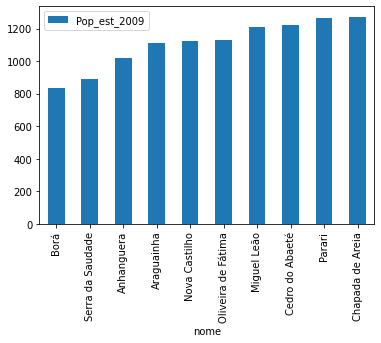

In [ ]:
cidades_menos_pop.plot(x='nome', y='Pop_est_2009', kind='bar')

### Gere um gráfico de pizza com a proporção da população do Brasil por região.

In [ ]:
populacao_df=  pd.concat([brasil_df[['Região','Pop_est_2009']]])

In [ ]:
populacao_por_regiao= populacao_df.groupby('Região').agg('sum')
populacao_por_regiao

,Pop_est_2009
Região,
CENTRO-OESTE,13773930
NORDESTE,53491940
NORTE,15359608
SUDESTE,80831550
SUL,27719118


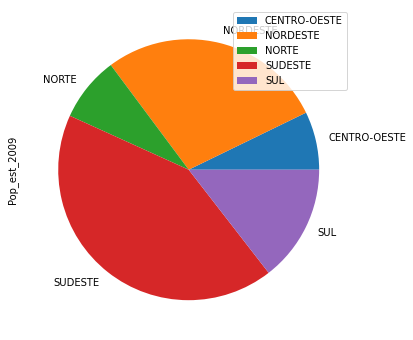

In [ ]:
pie_plot= populacao_por_regiao.plot.pie(x='Região', y='Pop_est_2009', figsize=(11,6))